In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

In [3]:
# Risk-Free Rate
annual_rf = 0.065
daily_rf = annual_rf / 252

In [4]:
# Calculate Sortino Ratio
results = []

for amfi_code, group in df.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()

    downside_returns = group[group["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    results.append({
        "amfi_code": amfi_code,
        "Mean_Daily_Return": mean_return,
        "Downside_Std": downside_std,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(results)

In [5]:
# Rank Funds
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df["Rank"] = range(1, len(sortino_df)+1)

In [6]:
# View Results
print(sortino_df.head(10))

    amfi_code  Mean_Daily_Return  Downside_Std  Sortino_Ratio  Rank
34     148567           0.001074      0.005428       2.385644     1
30     120843           0.001082      0.005531       2.364320     2
36     148569           0.001124      0.006404       2.146914     3
19     119551           0.000917      0.004887       2.140267     4
25     120505           0.001161      0.007067       2.029353     5
38     149323           0.001055      0.006750       1.875101     6
9      118632           0.000865      0.005211       1.850133     7
2      100033           0.001080      0.007133       1.829134     8
24     120504           0.000843      0.005145       1.805294     9
3      101206           0.000852      0.005238       1.799563    10


In [7]:
# Save CSV
sortino_df.to_csv(
    "../data/processed/sortino_ratio_ranking.csv",
    index=False
)

print("Sortino Ratio ranking saved successfully!")

Sortino Ratio ranking saved successfully!


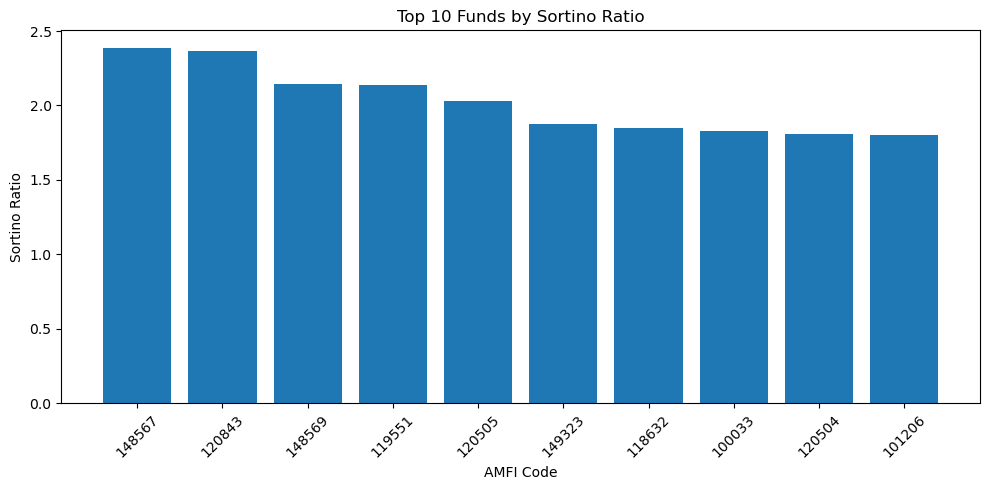

In [8]:
# Top 10 Bar Chart
top10 = sortino_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sortino_Ratio"]
)

plt.xticks(rotation=45)
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")
plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig("../reports/18_sortino_ratio_top10.png")

plt.show()

In [ ]:
## Insight

# The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility. Funds with higher Sortino Ratios generated better returns while experiencing lower downside risk, making them more attractive for risk-conscious investors.